In [86]:
import os
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [87]:
# Canonical reward parameters (define once here for notebook-wide tests)
# Edit these to change reward behaviour across all tests in this notebook
REWARD_PARAMS = {
    'goal_threshold': 2.0,  # Gaussian sigma: 3m so reward is non-zero throughout episode
    'goal_reward_base': 0.5,  # Per-step max reward at goal; lower since it accumulates every step
    'goal_distance_reference': 5.0,
    'use_scaled_goal': True,
    'distance_reward_scale': 5.0,
    'jerk_scale': 0.05,
    'obstacle_scale': 0.3,
    'gait_switch_penalty': 0.1,
    'instability_scale': 0.02,
    'time_penalty': 0.01,
    'velocity_error_scale': 0.01,
    'collision_penalty': 0.5,
    'normalize_distance': True
}

# Also create top-level variables for convenience
for k, v in REWARD_PARAMS.items():
    globals()[k] = v

print("Canonical REWARD_PARAMS defined for this notebook.")


Canonical REWARD_PARAMS defined for this notebook.


In [88]:
# Configuration
RECORDED_DATA_DIR = "/home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data"

# Find all HDF5 files and ROS bags
h5_files = glob.glob(os.path.join(RECORDED_DATA_DIR, "**/*.h5"), recursive=True)
bag_dirs = [d for d in glob.glob(os.path.join(RECORDED_DATA_DIR, "*")) if os.path.isdir(d)]

print(f"Found {len(h5_files)} HDF5 files")
print(f"Found {len(bag_dirs)} ROS bag directories")

if h5_files:
    print("\nHDF5 Files:")
    for f in sorted(h5_files, key=os.path.getmtime, reverse=True):
        size_mb = os.path.getsize(f) / (1024**2)
        print(f"  - {os.path.basename(f)} ({size_mb:.2f} MB)")
        
if bag_dirs:
    print("\nROS Bag Directories:")
    for d in sorted(bag_dirs, key=os.path.getmtime, reverse=True)[:5]:
        print(f"  - {os.path.basename(d)}")

Found 1 HDF5 files
Found 0 ROS bag directories

HDF5 Files:
  - spot_bag_20260421_102046_expert_medium_converted.h5 (0.57 MB)


In [89]:
def load_h5_episode(h5_path, max_retries=3, retry_delay=1.0):
    """Load episode data from HDF5 file with retry logic for locked files"""
    import time
    print(f"Loading: {os.path.basename(h5_path)}")
    
    # Retry logic in case file is locked
    for attempt in range(max_retries):
        try:
            episode = {}
            with h5py.File(h5_path, 'r', swmr=False) as f:
                # Print available datasets
                print("Available datasets:")
                def print_structure(name, obj):
                    if isinstance(obj, h5py.Dataset):
                        print(f"  {name}: shape={obj.shape}, dtype={obj.dtype}")
                f.visititems(print_structure)
                
                # Load observations
                obs_keys = ['state', 'velocities', 'actions', 'timestamps', 'locomotion_mode']
                for key in obs_keys:
                    path = f'observations/{key}' if 'observations' in f else key
                    if path in f:
                        episode[key] = f[path][()]
                    elif key in f:
                        episode[key] = f[key][()]
                    else:
                        if key != 'locomotion_mode':  # Don't warn about optional locomotion_mode
                            print(f"  Warning: {key} not found")
                
                # Load actions separately
                if 'actions' not in episode and 'actions' in f:
                    episode['actions'] = f['actions'][()]
                
                # Load local grids
                if 'observations/obstacle_grids' in f:
                    episode['obstacle_grids'] = f['observations/obstacle_grids'][()]
                if 'observations/terrain_grids' in f:
                    episode['terrain_grids'] = f['observations/terrain_grids'][()]
                    print(f"  ✓ Loaded terrain grids: {episode['terrain_grids'].shape}")
                
                # Load collision events
                if 'observations/collision_events' in f:
                    episode['collision_events'] = f['observations/collision_events'][()]
                    print(f"  ✓ Loaded collision events: {episode['collision_events'].shape}")
                elif 'collision_events' in f:
                    episode['collision_events'] = f['collision_events'][()]
                    print(f"  ✓ Loaded collision events: {episode['collision_events'].shape}")
                else:
                    print(f"  ⚠ Collision events not found in HDF5")
                
                # Load camera images - THIS IS CRITICAL FOR VISUALIZATION
                print("\nLoading sensor images and depth maps...")
                if 'observations/images_front' in f:
                    print(f"  Found observations/images_front, loading...")
                    episode['images_front'] = f['observations/images_front'][()]
                    print(f"  ✓ Loaded front camera: {episode['images_front'].shape}")
                else:
                    print(f"  ✗ observations/images_front not found")
                    
                if 'observations/image' in f:
                    episode['image'] = f['observations/image'][()]
                    print(f"  ✓ Loaded image: {episode['image'].shape}")
                
                # Load depth maps
                if 'observations/depth_registered_left' in f:
                    print(f"  Found observations/depth_registered_left, loading...")
                    episode['depth_registered_left'] = f['observations/depth_registered_left'][()]
                    print(f"  ✓ Loaded depth left: {episode['depth_registered_left'].shape}")
                else:
                    print(f"  ✗ observations/depth_registered_left not found")
                    
                if 'observations/depth_registered_right' in f:
                    print(f"  Found observations/depth_registered_right, loading...")
                    episode['depth_registered_right'] = f['observations/depth_registered_right'][()]
                    print(f"  ✓ Loaded depth right: {episode['depth_registered_right'].shape}")
                else:
                    print(f"  ✗ observations/depth_registered_right not found")
            
            return episode
        except (BlockingIOError, OSError) as e:
            if attempt < max_retries - 1:
                print(f"  File locked (attempt {attempt+1}/{max_retries}), retrying in {retry_delay}s...")
                time.sleep(retry_delay)
            else:
                print(f"  ✗ Failed to load file after {max_retries} attempts: {e}")
                raise

# Select the latest HDF5 file if available
if h5_files:
    selected_h5 = sorted(h5_files, key=os.path.getmtime, reverse=True)[0]
    print(f"\nLoading latest HDF5: {selected_h5}")
    episode_data = load_h5_episode(selected_h5)
    data_loaded_from = "H5"
else:
    print("No HDF5 files found. You'll need to convert a rosbag first.")
    print("Run: python convert_bag_to_hdf5.py <bag_path> --output <output_dir>")
    episode_data = None
    data_loaded_from = None


Loading latest HDF5: /home/maurits-heemskerk/Documents/Uni/Master_Thesis/openbots_backpack/src/packages/dataset/recorded_data/spot_bag_20260421_102046_expert_medium_converted.h5
Loading: spot_bag_20260421_102046_expert_medium_converted.h5
Available datasets:
  actions: shape=(23, 4), dtype=float32
  observations/collision_events: shape=(23,), dtype=bool
  observations/images_front: shape=(23, 49, 128, 3), dtype=uint8
  observations/locomotion_mode: shape=(23,), dtype=uint32
  observations/state: shape=(23, 7), dtype=float32
  observations/terrain_grids: shape=(23, 64, 64), dtype=float32
  observations/velocities: shape=(23, 6), dtype=float32
  rewards: shape=(23,), dtype=float32
  timestamps: shape=(23,), dtype=float64
  ✓ Loaded terrain grids: (23, 64, 64)
  ✓ Loaded collision events: (23,)

Loading sensor images and depth maps...
  Found observations/images_front, loading...
  ✓ Loaded front camera: (23, 49, 128, 3)
  ✗ observations/depth_registered_left not found
  ✗ observations/d

In [90]:
# Extract episode components
if episode_data:
    timestamps = episode_data.get('timestamps', np.arange(len(episode_data['state'])))
    states = episode_data['state']  # [N, 7] = [x, y, z, qx, qy, qz, qw]
    velocities = episode_data.get('velocities', None)  # [N, 6]
    actions = episode_data.get('actions', None)  # [N, 6]
    # Try both 'terrain_grids' and 'obstacle_grids' keys (depends on converter version)
    # NOTE: Terrain grids are already normalized at H5 conversion time (ground level = 0)
    obstacle_grids = episode_data.get('terrain_grids', episode_data.get('obstacle_grids', None))  # [N, H, W]
    collision_events = episode_data.get('collision_events', None)  # [N] boolean array of collision flags
    
    # Normalize time to start from 0 (visualization purposes only)
    timestamps = timestamps - timestamps[0]
    
    # Normalize position to start from (0, 0, 0)
    initial_position = states[0, :3].copy()
    states = states.copy()
    states[:, :3] = states[:, :3] - initial_position
    
    n_steps = len(states)
    print(f"\nEpisode Summary (Normalized):")
    print(f"  Steps: {n_steps}")
    print(f"  State shape: {states.shape}")
    print(f"  Velocities: {velocities.shape if velocities is not None else 'Not available'}")
    print(f"  Actions: {actions.shape if actions is not None else 'Not available'}")
    print(f"  Obstacle grids: {obstacle_grids.shape if obstacle_grids is not None else 'Not available'}")
    if obstacle_grids is not None:
        print(f"  Obstacle grids (min-max): {np.nanmin(obstacle_grids):.3f} to {np.nanmax(obstacle_grids):.3f}")
        print(f"  ✓ Terrain pre-normalized at H5 conversion (ground level = 0)")
    print(f"  Collision events: {collision_events.shape if collision_events is not None else 'Not available'}")
    if collision_events is not None:
        n_collisions = np.sum(collision_events)
        print(f"  ✓ Collision flags detected: {n_collisions} events")
    print(f"  Time range: {timestamps[0]:.2f} to {timestamps[-1]:.2f} seconds")
    print(f"  Start position (normalized): {states[0, :3]}")
    print(f"  Initial raw position: {initial_position}")
else:
    n_steps = 0
    print("No episode data loaded")


Episode Summary (Normalized):
  Steps: 23
  State shape: (23, 7)
  Velocities: (23, 6)
  Actions: (23, 4)
  Obstacle grids: (23, 64, 64)
  Obstacle grids (min-max): 0.000 to 1.782
  ✓ Terrain pre-normalized at H5 conversion (ground level = 0)
  Collision events: (23,)
  ✓ Collision flags detected: 0 events
  Time range: 0.00 to 6.26 seconds
  Start position (normalized): [0. 0. 0.]
  Initial raw position: [0. 0. 0.]


In [91]:
# Section 6: Noobs Reward Design (Updated v2)
# Distance-decrease reward + goal reach bonus + out-of-radius penalty

NOOBS_PARAMS = {
    # Distance-decrease reward: primary gradient signal
    # r = +delta_dist (positive when moving closer, negative when moving away)
    'distance_scale':       1.0,   # Scale of distance-decrease reward
    'goal_reach_threshold': 0.5,   # Distance in metres below which goal is reached
    'goal_reach_bonus':     1.0,   # One-time reward bonus when entering goal_reach_threshold
    # Out-of-radius penalty: when robot moves away from goal AFTER reaching it
    'goal_radius':          0.5,   # Metres (bubble around goal)
    'out_of_radius_penalty': 0.5,  # Penalty per step when moving away from goal after reaching
    # Action smoothness: only applied to continuous command dims (vx, vy, vyaw), not gait
    'smoothness_scale':     0.1,   # Action smoothness weight
    # Orientation-to-goal: penalty = -scale * (1 - cos(heading, goal_dir)) / 2
    # Range: [0, -scale/2] per step. 0.2 → max -0.1/step
    'orientation_scale':    0.1,   # Orientation-to-goal weight
    # Time penalty: constant per-step cost to encourage speed
    'time_penalty':         0.01,  # Fixed penalty per step
}

In [92]:
def compute_rewards_for_episode(states, actions, velocities, goal_xy=None, dt=0.1):
    """
    Compute noobs rewards for one episode using distance-decrease reward.
    
    Reward components:
    1. Distance-decrease reward: primary gradient (positive when approaching goal)
    2. Goal reach bonus: one-time reward when entering goal threshold
    3. Out-of-radius penalty: penalty when leaving goal after reaching it
    4. Action smoothness: penalizes jerk on continuous dims (vx, vy, vyaw)
    5. Orientation penalty: penalizes not facing goal direction
    6. Time penalty: constant cost per step
    
    states:     (T, 7)  [x, y, z, qx, qy, qz, qw]
    actions:    (T, 4)  [vx_cmd, vy_cmd, vyaw_cmd, gait]
    velocities: (T, 6)  [not used, kept for API compatibility]
    goal_xy:    (2,)    goal position [x, y], defaults to final position if None
    
    Returns: reward array of shape (T,)
    """
    T = len(states)

    distance_scale       = NOOBS_PARAMS['distance_scale']
    goal_threshold       = NOOBS_PARAMS['goal_reach_threshold']
    goal_bonus           = NOOBS_PARAMS['goal_reach_bonus']
    goal_radius          = NOOBS_PARAMS['goal_radius']
    out_of_radius_pen    = NOOBS_PARAMS['out_of_radius_penalty']
    smoothness_scale     = NOOBS_PARAMS['smoothness_scale']
    orientation_scale    = NOOBS_PARAMS['orientation_scale']
    time_penalty         = NOOBS_PARAMS['time_penalty']

    # Goal position (provided or default to final position)
    if goal_xy is None:
        goal_xy = states[-1, :2]
    goal_xy = goal_xy.astype(np.float32)

    # === Component 1: Distance-Decrease Reward (primary gradient) ===
    # r(t) = -(dist(t) - dist(t-1))
    # Positive when moving closer, negative when moving away
    dist_to_goal = np.linalg.norm(states[:, :2] - goal_xy, axis=1)
    dist_changes = np.diff(dist_to_goal, prepend=dist_to_goal[0])
    distance_rewards = -distance_scale * dist_changes  # (T,)  # NEGATIVE sign: positive reward when approaching

    # === Component 1b: One-time Goal Reach Bonus ===
    # +goal_bonus when entering the goal_threshold radius (transition 0→1)
    is_in_goal = dist_to_goal < goal_threshold  # (T,) boolean
    crossed_into_goal = np.diff(is_in_goal.astype(int), prepend=0) > 0
    goal_reach_bonus = np.where(crossed_into_goal, goal_bonus, 0.0)

    # === Mask out distance and bonus rewards after first goal entry ===
    first_goal_idx = np.argmax(is_in_goal)
    if not np.any(is_in_goal):
        mask = np.ones_like(distance_rewards, dtype=bool)
    else:
        mask = np.arange(len(distance_rewards)) <= first_goal_idx
    distance_rewards = distance_rewards * mask
    goal_reach_bonus = goal_reach_bonus * mask

    # === Component 1c: Out-of-Radius Penalty ===
    # Penalty when leaving the goal_radius bubble after having been inside
    was_in_goal = np.concatenate([[False], is_in_goal[:-1]])
    now_out_of_radius = was_in_goal & (dist_to_goal > goal_radius)
    left_goal_region = np.diff(is_in_goal.astype(int), prepend=0) < 0
    out_of_radius_penalty = np.where(now_out_of_radius & left_goal_region, -out_of_radius_pen, 0.0)

    # === Component 2: Action Smoothness Penalty ===
    # Only on continuous dims (vx, vy, vyaw) — index 3 is discrete gait
    if actions is not None and len(actions) > 1:
        action_diffs = np.diff(actions[:, :3], axis=0)
        action_magnitudes = np.linalg.norm(action_diffs, axis=1)
        jerk_penalties = -smoothness_scale * action_magnitudes
        jerk_penalties = np.pad(jerk_penalties, (1, 0), mode='constant', constant_values=0.0)
    else:
        jerk_penalties = np.zeros(T)

    # === Component 3: Orientation-to-Goal Penalty ===
    qx, qy, qz, qw = states[:, 3], states[:, 4], states[:, 5], states[:, 6]
    yaw = np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy ** 2 + qz ** 2))
    heading = np.stack([np.cos(yaw), np.sin(yaw)], axis=1)

    goal_dir = goal_xy - states[:, :2]
    goal_dist_2d = np.linalg.norm(goal_dir, axis=1, keepdims=True)
    goal_dir_norm = goal_dir / np.maximum(goal_dist_2d, 1e-6)

    cos_angle = np.sum(heading * goal_dir_norm, axis=1)
    orientation_penalties = -orientation_scale * (1.0 - cos_angle) / 2.0

    # === Component 4: Time Penalty ===
    time_penalties = np.full(T, -time_penalty)

    # === Combine all components ===
    rewards = (distance_rewards + goal_reach_bonus + out_of_radius_penalty + 
               jerk_penalties + orientation_penalties + time_penalties)

    return rewards.astype(np.float32)


## Section 2a: Sensor Observations with Normalized Data

Visualize sample sensor data (camera images and terrain grids) alongside normalized time and position - before reward computation.


Sensor data available:
  Images front: (23, 49, 128, 3)
  Depth left: Not available
  Depth right: Not available
  Terrain grids: (23, 64, 64)
  Terrain grids (min-max): 0.000 to 1.782
  ✓ Pre-normalized at H5 conversion (ground level = 0)
  Total steps: 23
  Using 4 sample indices from 23 available frames


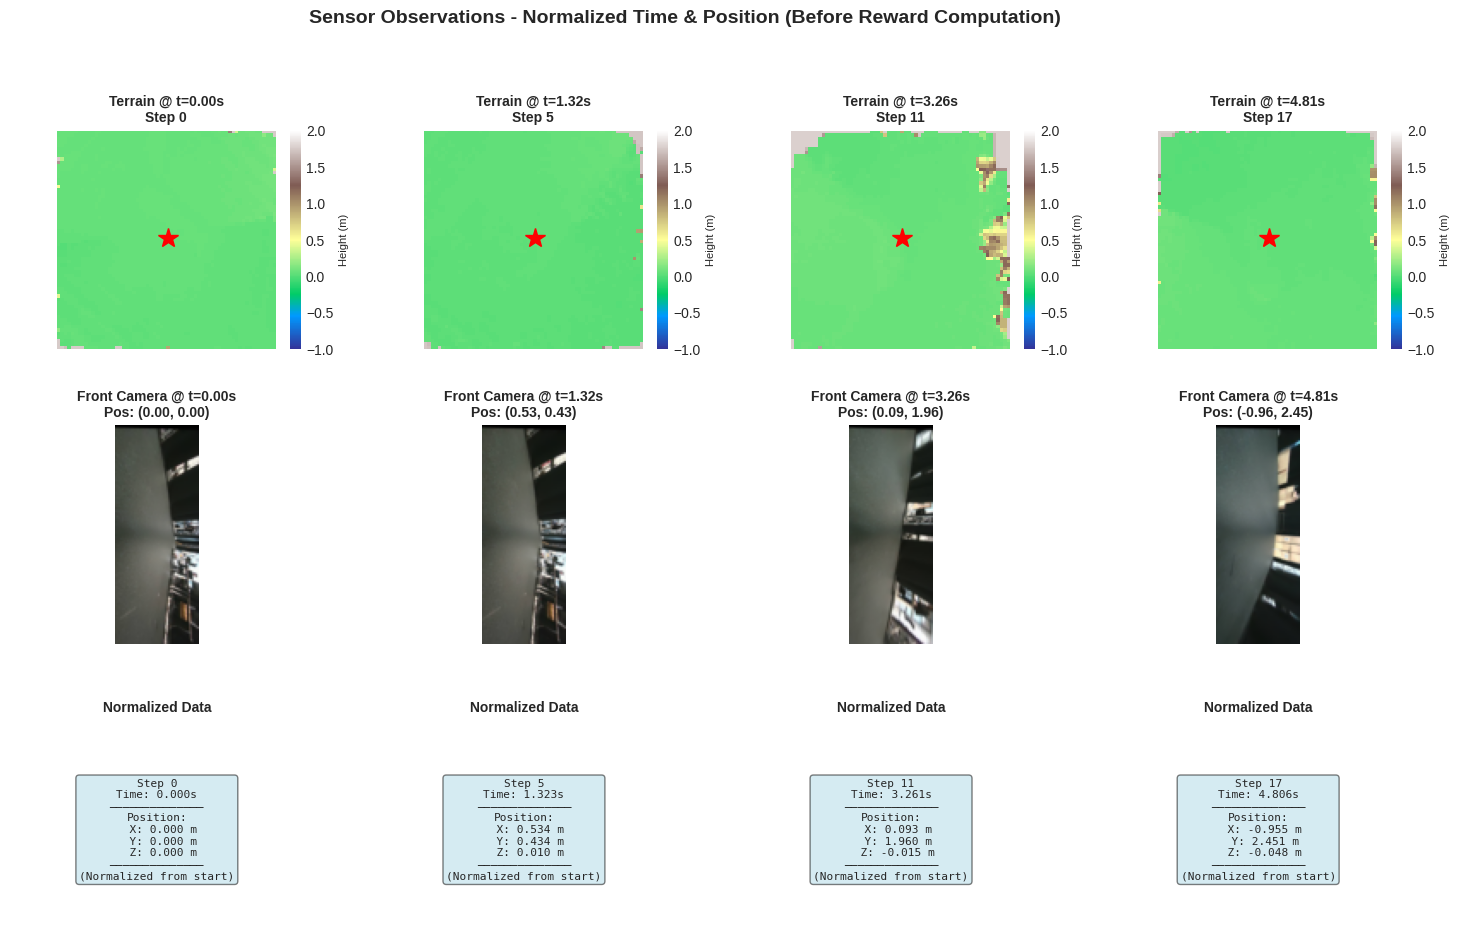

Sensor visualization saved!


In [93]:
if episode_data:
    # Load sensor data if available
    images_front = episode_data.get('images_front', None)
    depth_left = episode_data.get('depth_registered_left', None)
    depth_right = episode_data.get('depth_registered_right', None)
    # Use the already-normalized obstacle_grids from data loading section
    terrain_grids = obstacle_grids  # Already normalized to ground=0
    
    # Debug: Check what was loaded
    print("Sensor data available:")
    print(f"  Images front: {images_front.shape if images_front is not None else 'Not available'}")
    print(f"  Depth left: {depth_left.shape if depth_left is not None else 'Not available'}")
    print(f"  Depth right: {depth_right.shape if depth_right is not None else 'Not available'}")
    print(f"  Terrain grids: {terrain_grids.shape if terrain_grids is not None else 'Not available'}")
    if terrain_grids is not None:
        print(f"  Terrain grids (min-max): {np.nanmin(terrain_grids):.3f} to {np.nanmax(terrain_grids):.3f}")
        print(f"  ✓ Pre-normalized at H5 conversion (ground level = 0)")
    print(f"  Total steps: {n_steps}")
    
    # Select sample indices from the episode - align with available data
    max_len = max(
        len(images_front) if images_front is not None else 0,
        len(depth_left) if depth_left is not None else 0,
        len(terrain_grids) if terrain_grids is not None else 0,
        n_steps
    )
    
    num_samples = min(max_len, n_steps) if max_len > 0 else 0
    sample_indices = [0, num_samples // 4, num_samples // 2, 3 * num_samples // 4] if num_samples > 0 else []
    print(f"  Using {len(sample_indices)} sample indices from {num_samples} available frames")
    
    if sample_indices:
        # Determine how many rows we actually need
        n_rows = 0
        if terrain_grids is not None:
            n_rows += 1
        if images_front is not None:
            n_rows += 1
        if depth_left is not None:
            n_rows += 1
        n_rows += 1  # Always add reward breakdown row (will show 0 since not computed yet)
        
        fig = plt.figure(figsize=(18, 3.5 * n_rows))
        gs = fig.add_gridspec(n_rows, 4, hspace=0.35, wspace=0.25)
        
        row = 0
        
        # Row: Terrain grids with normalized height
        if terrain_grids is not None:
            for col, idx in enumerate(sample_indices):
                ax = fig.add_subplot(gs[row, col])
                grid = terrain_grids[idx]
                im = ax.imshow(grid, cmap='terrain', origin='lower', vmin=-1, vmax=2)
                ax.plot(grid.shape[1]//2, grid.shape[0]//2, 'r*', markersize=15, label='Robot (h=0)')
                ax.set_title(f'Terrain @ t={timestamps[idx]:.2f}s\nStep {idx}', fontsize=10, fontweight='bold')
                ax.axis('off')
                cbar = plt.colorbar(im, ax=ax, fraction=0.046)
                cbar.set_label('Height (m)', fontsize=8)
            row += 1
        
        # Row: Front camera images
        if images_front is not None:
            for col, idx in enumerate(sample_indices):
                ax = fig.add_subplot(gs[row, col])
                img = images_front[idx]
                # Rotate clockwise 90 degrees
                img_rotated = np.rot90(img, k=-1)
                # Handle different image formats
                if img_rotated.dtype == np.uint8:
                    ax.imshow(img_rotated)
                else:
                    # Normalize if needed
                    img_norm = (img_rotated - img_rotated.min()) / (img_rotated.max() - img_rotated.min() + 1e-6)
                    ax.imshow(img_norm)
                ax.set_title(f'Front Camera @ t={timestamps[idx]:.2f}s\nPos: ({states[idx, 0]:.2f}, {states[idx, 1]:.2f})', fontsize=10, fontweight='bold')
                ax.axis('off')
            row += 1
        
        # Row: Depth maps (left)
        if depth_left is not None:
            for col, idx in enumerate(sample_indices):
                ax = fig.add_subplot(gs[row, col])
                depth = depth_left[idx]
                # Rotate clockwise 90 degrees
                depth_rotated = np.rot90(depth, k=-1)
                im = ax.imshow(depth_rotated, cmap='viridis')
                ax.set_title(f'Depth Left @ t={timestamps[idx]:.2f}s\nH: {states[idx, 2]:.2f}m', fontsize=10, fontweight='bold')
                ax.axis('off')
                plt.colorbar(im, ax=ax, fraction=0.046)
            row += 1
        
        # Row: Position info
        for col, idx in enumerate(sample_indices):
            ax = fig.add_subplot(gs[row, col])
            pos_text = (
                f"Step {idx}\n"
                f"Time: {timestamps[idx]:.3f}s\n"
                f"──────────────\n"
                f"Position:\n"
                f"  X: {states[idx, 0]:.3f} m\n"
                f"  Y: {states[idx, 1]:.3f} m\n"
                f"  Z: {states[idx, 2]:.3f} m\n"
                f"──────────────\n"
                f"(Normalized from start)"
            )
            ax.text(0.5, 0.5, pos_text, fontsize=8, ha='center', va='center', 
                   family='monospace', transform=ax.transAxes,
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
            ax.axis('off')
            ax.set_title('Normalized Data', fontsize=10, fontweight='bold')
        
        fig.suptitle('Sensor Observations - Normalized Time & Position (Before Reward Computation)', fontsize=14, fontweight='bold', y=0.995)
        plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/sensor_normalized.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        
        print("Sensor visualization saved!")
    else:
        print("No sample indices available")
else:
    print("No episode data available")

In [94]:
# (Old RewardComputer class remnant removed - gait switching is no longer used in reward model)
print("Reward model: distance-decrease + goal bonus + smoothness + orientation + time penalty")

Reward model: distance-decrease + goal bonus + smoothness + orientation + time penalty


## Section 1b: Interactive Timestep Viewer

Select a specific timestep to visualize terrain map and camera image at that exact moment.


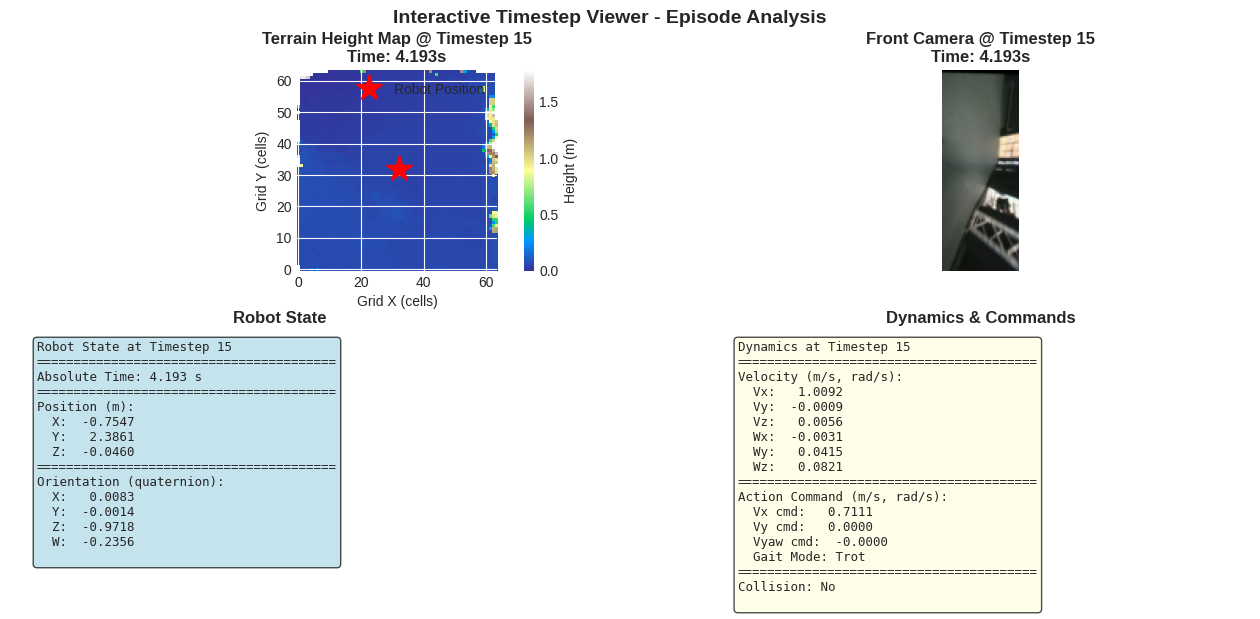

✓ Timestep 15 visualization complete!


In [95]:
        # ===== TIMESTEP SELECTOR - Edit this variable to view any timestep =====
        selected_timestep = 15  # Change this to any valid timestep (0 to n_steps-1)
        # =========================================================================

        if episode_data and n_steps > 0:
            # Load locomotion modes if not already loaded
            if 'locomotion_modes' not in locals() or locomotion_modes is None:
                locomotion_modes = episode_data.get('locomotion_mode', None)
            
            # Validate timestep
            if selected_timestep < 0 or selected_timestep >= n_steps:
                print(f"ERROR: Invalid timestep {selected_timestep}. Valid range: 0 to {n_steps-1}")
            else:
                idx = selected_timestep
                
                # Create figure with terrain + camera
                fig = plt.figure(figsize=(16, 6))
                gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)
                
                # 1. Terrain Grid
                if terrain_grids is not None and idx < len(terrain_grids):
                    ax1 = fig.add_subplot(gs[0, 0])
                    grid = terrain_grids[idx]
                    im1 = ax1.imshow(grid, cmap='terrain', origin='lower', vmin=np.nanmin(terrain_grids), vmax=np.nanmax(terrain_grids))
                    ax1.plot(grid.shape[1]//2, grid.shape[0]//2, 'r*', markersize=20, label='Robot Position')
                    ax1.set_title(f'Terrain Height Map @ Timestep {idx}\nTime: {timestamps[idx]:.3f}s', fontsize=12, fontweight='bold')
                    ax1.set_xlabel('Grid X (cells)')
                    ax1.set_ylabel('Grid Y (cells)')
                    ax1.legend(fontsize=10)
                    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046)
                    cbar1.set_label('Height (m)', fontsize=10)
                
                # 2. Front Camera Image
                if images_front is not None and idx < len(images_front):
                    ax2 = fig.add_subplot(gs[0, 1])
                    img = images_front[idx]
                    img_rotated = np.rot90(img, k=-1)
                    # Handle different image formats
                    if img_rotated.dtype == np.uint8:
                        ax2.imshow(img_rotated)
                    else:
                        img_norm = (img_rotated - img_rotated.min()) / (img_rotated.max() - img_rotated.min() + 1e-6)
                        ax2.imshow(img_norm)
                    ax2.set_title(f'Front Camera @ Timestep {idx}\nTime: {timestamps[idx]:.3f}s', fontsize=12, fontweight='bold')
                    ax2.axis('off')
                
                # 3. Robot State Information
                ax3 = fig.add_subplot(gs[1, 0])
                state_text = (
                    f"Robot State at Timestep {idx}\n"
                    f"{'='*40}\n"
                    f"Absolute Time: {timestamps[idx]:.3f} s\n"
                    f"{'='*40}\n"
                    f"Position (m):\n"
                    f"  X: {states[idx, 0]:8.4f}\n"
                    f"  Y: {states[idx, 1]:8.4f}\n"
                    f"  Z: {states[idx, 2]:8.4f}\n"
                    f"{'='*40}\n"
                    f"Orientation (quaternion):\n"
                    f"  X: {states[idx, 3]:8.4f}\n"
                    f"  Y: {states[idx, 4]:8.4f}\n"
                    f"  Z: {states[idx, 5]:8.4f}\n"
                    f"  W: {states[idx, 6]:8.4f}\n"
                )
                ax3.text(0.05, 0.95, state_text, fontsize=9, family='monospace', 
                        transform=ax3.transAxes, va='top',
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
                ax3.axis('off')
                ax3.set_title('Robot State', fontsize=12, fontweight='bold')
                
                # 4. Velocity & Action Information (4D action space: [vx, vy, vyaw, gait_selection])
                ax4 = fig.add_subplot(gs[1, 1])
                gait_idx = int(actions[idx, 3])
                gait_mode = ['Crawl', 'Trot'][gait_idx] if gait_idx in [0, 1] else f'Unknown ({gait_idx})'
                
                vel_action_text = (
                    f"Dynamics at Timestep {idx}\n"
                    f"{'='*40}\n"
                    f"Velocity (m/s, rad/s):\n"
                    f"  Vx: {velocities[idx, 0]:8.4f}\n"
                    f"  Vy: {velocities[idx, 1]:8.4f}\n"
                    f"  Vz: {velocities[idx, 2]:8.4f}\n"
                    f"  Wx: {velocities[idx, 3]:8.4f}\n"
                    f"  Wy: {velocities[idx, 4]:8.4f}\n"
                    f"  Wz: {velocities[idx, 5]:8.4f}\n"
                    f"{'='*40}\n"
                    f"Action Command (m/s, rad/s):\n"
                    f"  Vx cmd: {actions[idx, 0]:8.4f}\n"
                    f"  Vy cmd: {actions[idx, 1]:8.4f}\n"
                    f"  Vyaw cmd: {actions[idx, 2]:8.4f}\n"
                    f"  Gait Mode: {gait_mode}\n"
                    f"{'='*40}\n"
                )
                
                # Add collision info if available
                if collision_events is not None and idx < len(collision_events):
                    collision_str = 'YES ⚠️' if collision_events[idx] else 'No'
                    vel_action_text += f"Collision: {collision_str}\n"
                
                ax4.text(0.05, 0.95, vel_action_text, fontsize=9, family='monospace',
                        transform=ax4.transAxes, va='top',
                        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
                ax4.axis('off')
                ax4.set_title('Dynamics & Commands', fontsize=12, fontweight='bold')
                
                fig.suptitle(f'Interactive Timestep Viewer - Episode Analysis', fontsize=14, fontweight='bold')
                plt.savefig(f'/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/timestep_{idx}_viewer.png',
                            dpi=150, bbox_inches='tight')
                plt.show()
                
                print(f"✓ Timestep {idx} visualization complete!")
        else:
            print("Cannot visualize: no episode data available or n_steps is 0")

## Section 1c: Reward Components Analysis (10 Components)

Comprehensive visualization of all reward signals throughout the episode.


In [96]:
if episode_data and n_steps > 0:
    # Ensure locomotion_modes has correct shape (if missing, create placeholder)
    if episode_data.get('locomotion_mode', None) is None:
        locomotion_modes = np.zeros(n_steps, dtype=int)
    else:
        locomotion_modes = episode_data['locomotion_mode']
        if len(locomotion_modes) != n_steps:
            if len(locomotion_modes) < n_steps:
                locomotion_modes = np.pad(locomotion_modes, (0, n_steps - len(locomotion_modes)), mode='edge')
            else:
                locomotion_modes = locomotion_modes[:n_steps]

    # ===== COMPUTE REWARD USING NEW DISTANCE-DECREASE FUNCTION =====
    # Use the updated compute_rewards_for_episode function
    rewards = compute_rewards_for_episode(states, actions, velocities)
    
    print(f"\nReward Statistics:")
    print(f"  Shape: {rewards.shape}")
    print(f"  Min: {rewards.min():.4f}")
    print(f"  Max: {rewards.max():.4f}")
    print(f"  Mean: {rewards.mean():.4f}")
    print(f"  Sum: {rewards.sum():.4f}")
    print(f"  Positive rewards: {(rewards > 0).sum()} / {len(rewards)}")
    print(f"  Negative rewards: {(rewards < 0).sum()} / {len(rewards)}")
    
else:
    print("No episode data loaded")
    rewards = None


Reward Statistics:
  Shape: (23,)
  Min: -0.6099
  Max: 1.1392
  Mean: -0.0067
  Sum: -0.1539
  Positive rewards: 7 / 23
  Negative rewards: 16 / 23


## Section 2b: Compute Reward Components

We'll implement individual reward functions for each component, then combine them.

In [97]:
# Cell 13 was old RewardComputer initialization - now using function-based approach from cell 11
# All reward components are already computed there
print("Using distance-decrease reward model from cell 11")

Using distance-decrease reward model from cell 11


## Section 3: Calculate Total Episode Reward

In [98]:
# Cell 15: Old method-based reward computation - now replaced with function call
# The rewards array from cell 11 contains all components already combined

if rewards is not None:
    print(f"\nReward Component Analysis:")
    print(f"  Model: Distance-Decrease (gradient-based)")
    print(f"  Components:")
    print(f"    - Distance-Decrease Reward (primary signal)")
    print(f"    - Goal-Reach Bonus (one-time transition reward)")
    print(f"    - Out-of-Radius Penalty (prevents leaving goal)")
    print(f"    - Action Smoothness Penalty")
    print(f"    - Orientation-to-Goal Penalty")
    print(f"    - Time Penalty")
    print(f"\n  Reward Statistics:")
    print(f"    Min: {rewards.min():.4f}")
    print(f"    Max: {rewards.max():.4f}")
    print(f"    Mean: {rewards.mean():.4f}")
    print(f"    Median: {np.median(rewards):.4f}")
    print(f"    Std: {rewards.std():.4f}")
    print(f"\n  Histogram:")
    n, bins = np.histogram(rewards, bins=20)
    for i in range(len(bins)-1):
        bar_len = int(n[i] / n.max() * 30)
        print(f"    [{bins[i]:+.3f}, {bins[i+1]:+.3f}]: {'█' * bar_len} ({int(n[i])})")
else:
    print("No rewards computed yet - run cell 11 first")


Reward Component Analysis:
  Model: Distance-Decrease (gradient-based)
  Components:
    - Distance-Decrease Reward (primary signal)
    - Goal-Reach Bonus (one-time transition reward)
    - Out-of-Radius Penalty (prevents leaving goal)
    - Action Smoothness Penalty
    - Orientation-to-Goal Penalty
    - Time Penalty

  Reward Statistics:
    Min: -0.6099
    Max: 1.1392
    Mean: -0.0067
    Median: -0.1098
    Std: 0.3100

  Histogram:
    [-0.610, -0.522]: ███ (1)
    [-0.522, -0.435]:  (0)
    [-0.435, -0.348]:  (0)
    [-0.348, -0.260]: ███ (1)
    [-0.260, -0.173]: ██████ (2)
    [-0.173, -0.085]: ██████████████████████████████ (9)
    [-0.085, +0.002]: ██████████ (3)
    [+0.002, +0.090]: ███ (1)
    [+0.090, +0.177]: ██████████ (3)
    [+0.177, +0.265]:  (0)
    [+0.265, +0.352]: ██████ (2)
    [+0.352, +0.440]:  (0)
    [+0.440, +0.527]:  (0)
    [+0.527, +0.614]:  (0)
    [+0.614, +0.702]:  (0)
    [+0.702, +0.789]:  (0)
    [+0.789, +0.877]:  (0)
    [+0.877, +0.964]:  (

Reward Component Breakdown:
  distance_rewards    : min=-0.0518, max=+0.3313, mean=+0.0608, sum=+1.3976
  goal_bonus          : min=+0.0000, max=+1.0000, mean=+0.0435, sum=+1.0000
  out_of_radius       : min=-0.5000, max=+0.0000, mean=-0.1739, sum=-4.0000
  smoothness          : min=-0.0856, max=-0.0000, mean=-0.0105, sum=-0.2413
  orientation         : min=-0.1000, max=-0.0025, mean=-0.0582, sum=-1.3390
  time_penalty        : min=-0.0100, max=+0.0000, mean=-0.0078, sum=-0.1800


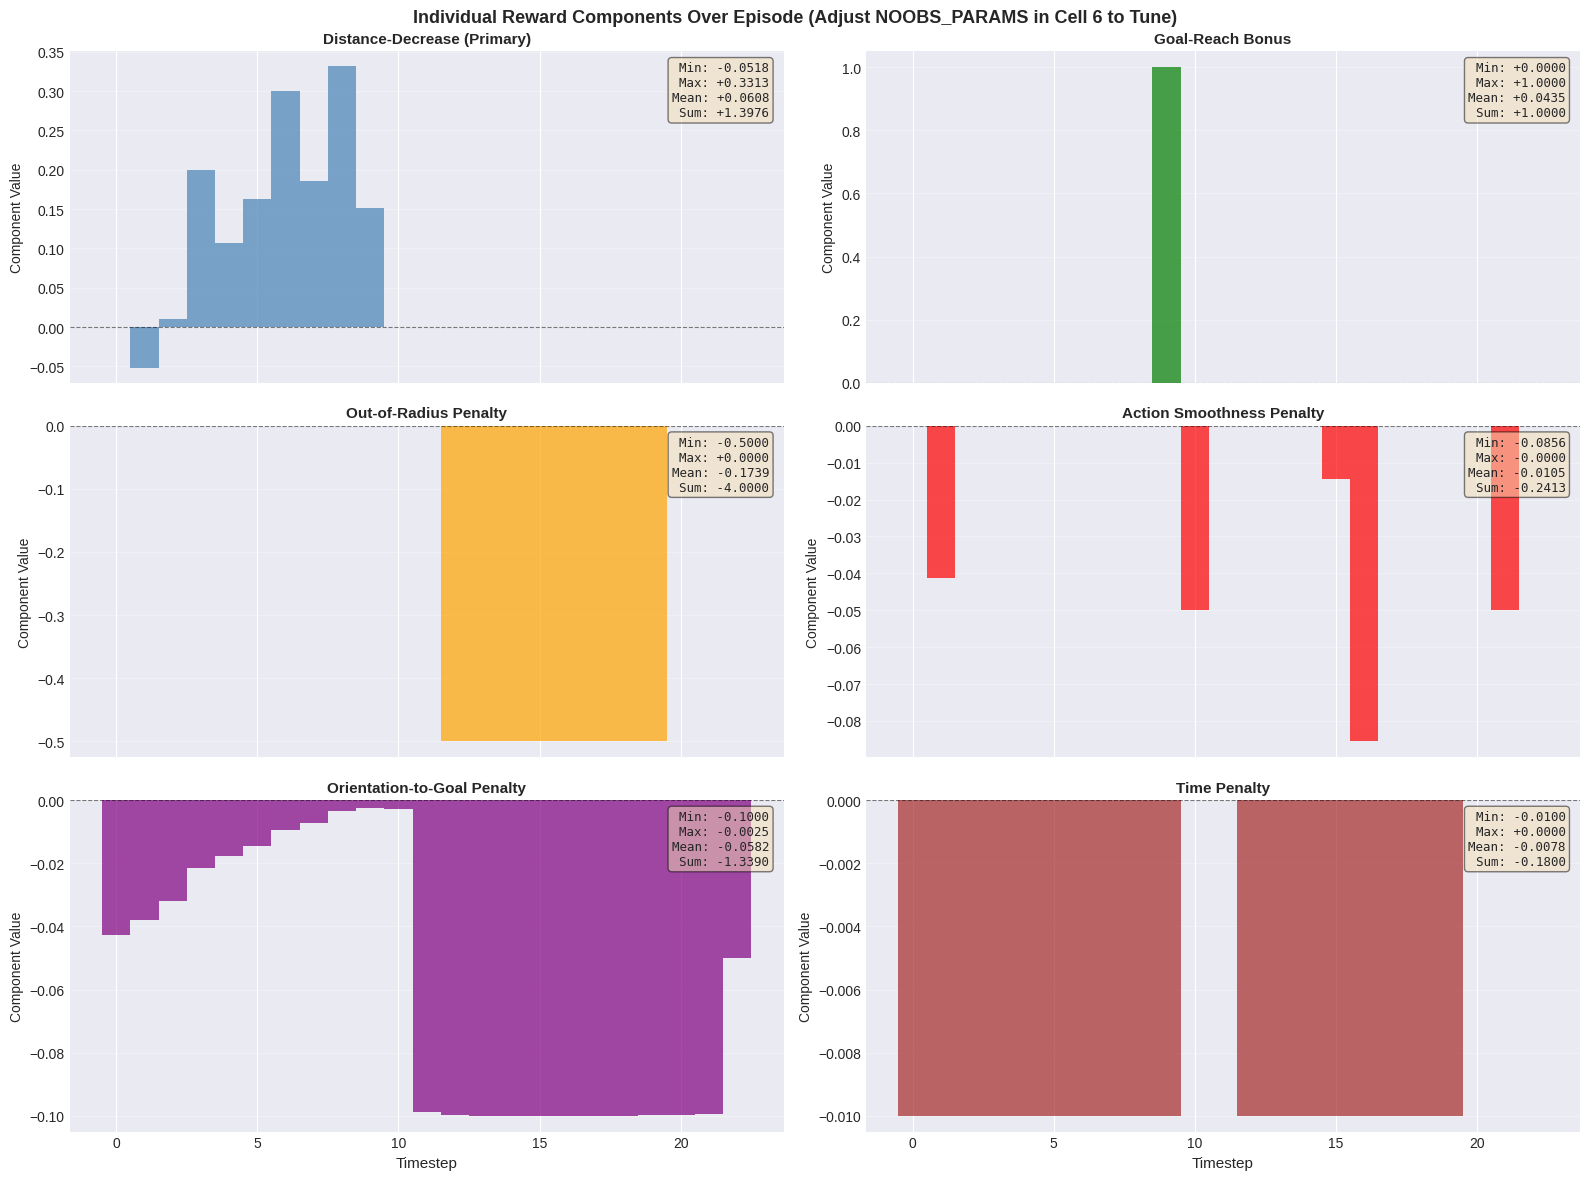


✓ Component visualization saved to: reward_components_breakdown.png


In [99]:
# Decompose and visualize individual reward components for tuning

def decompose_rewards_for_episode(states, actions, velocities, goal_xy=None, dt=0.1):
    """
    Returns a dict of all reward components for a single episode.
    Components: distance_rewards, goal_bonus, out_of_radius, smoothness, orientation, time_penalty
    """
    params = REWARD_PARAMS
    distance_scale = params.get('distance_scale', 1.0)
    goal_threshold = params.get('goal_reach_threshold', 0.5)
    goal_bonus = params.get('goal_reach_bonus', 1.0)
    goal_radius = params.get('goal_radius', 0.5)
    out_of_radius_pen = params.get('out_of_radius_penalty', 0.5)
    smoothness_scale = params.get('smoothness_scale', 0.1) * 0.5  # Halved
    orientation_scale = params.get('orientation_scale', 0.1)
    time_penalty = params.get('time_penalty', 0.01)

    T = states.shape[0]
    if goal_xy is None:
        goal_xy = states[-1, :2]
    goal_xy = goal_xy.astype(np.float32)

    dist_to_goal = np.linalg.norm(states[:, :2] - goal_xy, axis=1)
    dist_changes = np.diff(dist_to_goal, prepend=dist_to_goal[0])
    distance_rewards = -distance_scale * dist_changes

    is_in_goal = dist_to_goal < goal_threshold
    crossed_into_goal = np.diff(is_in_goal.astype(int), prepend=0) > 0
    goal_reach_bonus_arr = np.where(crossed_into_goal, goal_bonus, 0.0)

    first_goal_idx = np.argmax(is_in_goal)
    if not np.any(is_in_goal):
        mask = np.ones_like(distance_rewards, dtype=bool)
    else:
        mask = np.arange(len(distance_rewards)) <= first_goal_idx
    distance_rewards_masked = distance_rewards * mask
    goal_reach_bonus_masked = goal_reach_bonus_arr * mask

    # Persistent out-of-radius penalty after first goal entry
    if np.any(is_in_goal):
        after_goal_entry = np.arange(len(is_in_goal)) > first_goal_idx
        outside_radius = dist_to_goal > goal_radius
        out_of_radius_penalty = np.where(after_goal_entry & outside_radius, -out_of_radius_pen, 0.0)
    else:
        out_of_radius_penalty = np.zeros_like(dist_to_goal)

    if actions is not None and len(actions) > 1:
        action_diffs = np.diff(actions[:, :3], axis=0)
        action_magnitudes = np.linalg.norm(action_diffs, axis=1)
        jerk_penalties = -smoothness_scale * action_magnitudes
        jerk_penalties = np.pad(jerk_penalties, (1, 0), mode='constant', constant_values=0.0)
    else:
        jerk_penalties = np.zeros(T)

    qx, qy, qz, qw = states[:, 3], states[:, 4], states[:, 5], states[:, 6]
    yaw = np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy ** 2 + qz ** 2))
    heading = np.stack([np.cos(yaw), np.sin(yaw)], axis=1)
    goal_dir = goal_xy - states[:, :2]
    goal_dist_2d = np.linalg.norm(goal_dir, axis=1, keepdims=True)
    goal_dir_norm = goal_dir / np.maximum(goal_dist_2d, 1e-6)
    cos_angle = np.sum(heading * goal_dir_norm, axis=1)
    orientation_penalties = -orientation_scale * (1.0 - cos_angle) / 2.0

    # Time penalty: only apply outside goal radius after first entry
    if np.any(is_in_goal):
        after_goal_entry = np.arange(len(is_in_goal)) > first_goal_idx
        outside_radius = dist_to_goal > goal_radius
        time_penalties = np.where(after_goal_entry & outside_radius, -time_penalty, 0.0)
        # Before first entry, always apply time penalty
        time_penalties[:first_goal_idx+1] = -time_penalty
    else:
        time_penalties = np.full(T, -time_penalty)

    return {
        'distance_rewards': distance_rewards_masked,
        'goal_bonus': goal_reach_bonus_masked,
        'out_of_radius': out_of_radius_penalty,
        'smoothness': jerk_penalties,
        'orientation': orientation_penalties,
        'time_penalty': time_penalties,
    }

if episode_data and rewards is not None:
    # Decompose rewards into individual components
    components = decompose_rewards_for_episode(states, actions, velocities)

    print("Reward Component Breakdown:")
    for name, values in components.items():
        print(f"  {name:20s}: min={values.min():+.4f}, max={values.max():+.4f}, mean={values.mean():+.4f}, sum={values.sum():+.4f}")

    # Create subplot visualization for each component
    fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
    timesteps = np.arange(n_steps)

    component_names = [
        ('distance_rewards', 'Distance-Decrease (Primary)', 'steelblue'),
        ('goal_bonus', 'Goal-Reach Bonus', 'green'),
        ('out_of_radius', 'Out-of-Radius Penalty', 'orange'),
        ('smoothness', 'Action Smoothness Penalty', 'red'),
        ('orientation', 'Orientation-to-Goal Penalty', 'purple'),
        ('time_penalty', 'Time Penalty', 'brown'),
    ]

    axes_flat = axes.flatten()
    for idx, (key, label, color) in enumerate(component_names):
        ax = axes_flat[idx]
        component = components[key]

        # Bar chart with positive/negative separation
        ax.bar(timesteps, component, color=color, alpha=0.7, width=1.0)
        ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)

        # Add stats
        stats_text = f"Min: {component.min():+.4f}\nMax: {component.max():+.4f}\nMean: {component.mean():+.4f}\nSum: {component.sum():+.4f}"
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
               fontsize=9, verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), family='monospace')

        ax.set_ylabel('Component Value', fontsize=10)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

    axes_flat[-1].set_xlabel('Timestep', fontsize=11)
    axes_flat[-2].set_xlabel('Timestep', fontsize=11)

    fig.suptitle('Individual Reward Components Over Episode (Adjust NOOBS_PARAMS in Cell 6 to Tune)', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/reward_components_breakdown.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✓ Component visualization saved to: reward_components_breakdown.png")
else:
    print("Cannot decompose: missing episode data or rewards")


## Section 4: Visualize Rewards Over Time

In [100]:
if episode_data and n_steps > 0:
    print("=" * 70)
    print("DEBUG: TERRAIN & OBSTACLE ANALYSIS")
    print("=" * 70)
    
    if obstacle_grids is None:
        print("✗ No terrain grids loaded!")
    else:
        print(f"\nTerrain Grids Shape: {obstacle_grids.shape}")
        print(f"Data Type: {obstacle_grids.dtype}")
        
        # Check for NaN and invalid values
        n_nan = np.isnan(obstacle_grids).sum()
        n_inf = np.isinf(obstacle_grids).sum()
        print(f"NaN values: {n_nan} / {obstacle_grids.size}")
        print(f"Inf values: {n_inf} / {obstacle_grids.size}")
        
        # Overall statistics
        valid_mask = ~(np.isnan(obstacle_grids) | np.isinf(obstacle_grids))
        if valid_mask.sum() > 0:
            print(f"\nValid (non-NaN, non-Inf) cells: {valid_mask.sum()} / {obstacle_grids.size}")
            print(f"  Min height: {obstacle_grids[valid_mask].min():.4f} m")
            print(f"  Max height: {obstacle_grids[valid_mask].max():.4f} m")
            print(f"  Mean height: {obstacle_grids[valid_mask].mean():.4f} m")
            print(f"  Std height:  {obstacle_grids[valid_mask].std():.4f} m")
        
        # Estimate grid resolution from grid size
        # SPOT local grids are typically 128x128 cells covering ~6.4m x 6.4m area
        grid_h, grid_w = obstacle_grids[0].shape
        est_coverage = 6.4  # meters (typical SPOT local grid coverage)
        est_resolution = est_coverage / grid_h
        print(f"\nGrid Size: {grid_h} x {grid_w} cells")
        print(f"Estimated coverage: ~{est_coverage}m x {est_coverage}m")
        print(f"Estimated resolution: ~{est_resolution:.3f} m/cell")
        
        # Terrain roughness analysis
        print(f"\nTerrain Roughness Analysis (Height Variance):")
        roughness_per_frame = []
        max_slope_per_frame = []
        
        for grid in obstacle_grids:
            # Compute height gradients (slopes)
            if grid.size > 0 and valid_mask[0].sum() > 0:
                # Use finite differences to compute slopes
                gy, gx = np.gradient(grid)
                slope_magnitude = np.sqrt(gx**2 + gy**2)
                
                # Remove NaN slopes
                valid_slope = slope_magnitude[~np.isnan(slope_magnitude)]
                if len(valid_slope) > 0:
                    roughness_per_frame.append(np.std(valid_slope))
                    max_slope_per_frame.append(np.max(valid_slope))
                else:
                    roughness_per_frame.append(0.0)
                    max_slope_per_frame.append(0.0)
            else:
                roughness_per_frame.append(0.0)
                max_slope_per_frame.append(0.0)
        
        roughness_per_frame = np.array(roughness_per_frame)
        max_slope_per_frame = np.array(max_slope_per_frame)
        
        print(f"  Mean terrain roughness (slope std): {roughness_per_frame.mean():.4f}")
        print(f"  Max terrain roughness: {roughness_per_frame.max():.4f}")
        print(f"  Mean max slope per frame: {max_slope_per_frame.mean():.4f}")
        print(f"  Max slope encountered: {max_slope_per_frame.max():.4f}")
        
        # Obstacle detection analysis
        collision_radius = 0.5  # 50cm collision radius
        collision_radius_cells = collision_radius / est_resolution
        gentle_obstacle_threshold = 0.1   # 10cm step
        severe_obstacle_threshold = 0.3   # 30cm step
        
        print(f"\nObstacle Detection with {collision_radius}m Collision Radius:")
        print(f"  Collision radius in cells: {collision_radius_cells:.1f}")
        print(f"  Gentle obstacle threshold (step >10cm): {gentle_obstacle_threshold}m")
        print(f"  Severe obstacle threshold (step >30cm): {severe_obstacle_threshold}m")
        
        gentle_obstacles_per_frame = []
        severe_obstacles_per_frame = []
        
        for grid in obstacle_grids:
            h, w = grid.shape
            center_y, center_x = h / 2, w / 2
            
            # Create circular mask
            yy, xx = np.ogrid[:h, :w]
            distance_from_center = np.sqrt((yy - center_y)**2 + (xx - center_x)**2)
            in_radius = distance_from_center <= collision_radius_cells
            
            # Get heights in collision radius
            grid_in_radius = grid[in_radius]
            valid_heights = grid_in_radius[~np.isnan(grid_in_radius)]
            
            if len(valid_heights) > 0:
                # Obstacles: heights significantly above minimum (ground)
                ground_level = np.min(valid_heights)
                height_above_ground = valid_heights - ground_level
                
                gentle_obstacles = np.sum(height_above_ground > gentle_obstacle_threshold)
                severe_obstacles = np.sum(height_above_ground > severe_obstacle_threshold)
                
                gentle_obstacles_per_frame.append(gentle_obstacles)
                severe_obstacles_per_frame.append(severe_obstacles)
            else:
                gentle_obstacles_per_frame.append(0)
                severe_obstacles_per_frame.append(0)
        
        gentle_obstacles_per_frame = np.array(gentle_obstacles_per_frame)
        severe_obstacles_per_frame = np.array(severe_obstacles_per_frame)
        
        n_frames_gentle = (gentle_obstacles_per_frame > 0).sum()
        n_frames_severe = (severe_obstacles_per_frame > 0).sum()
        
        print(f"\n  Frames with obstacles >10cm: {n_frames_gentle} / {n_steps}")
        print(f"  Frames with obstacles >30cm: {n_frames_severe} / {n_steps}")
        print(f"  Mean gentle obstacles/frame: {gentle_obstacles_per_frame.mean():.1f}")
        print(f"  Mean severe obstacles/frame: {severe_obstacles_per_frame.mean():.1f}")
        print(f"\n✓ Terrain analysis complete")
    
    print("=" * 70)

DEBUG: TERRAIN & OBSTACLE ANALYSIS

Terrain Grids Shape: (23, 64, 64)
Data Type: float32
NaN values: 0 / 94208
Inf values: 0 / 94208

Valid (non-NaN, non-Inf) cells: 94208 / 94208
  Min height: 0.0000 m
  Max height: 1.7820 m
  Mean height: 0.0912 m
  Std height:  0.2467 m

Grid Size: 64 x 64 cells
Estimated coverage: ~6.4m x 6.4m
Estimated resolution: ~0.100 m/cell

Terrain Roughness Analysis (Height Variance):
  Mean terrain roughness (slope std): 0.1962
  Max terrain roughness: 0.2594
  Mean max slope per frame: 2.0529
  Max slope encountered: 2.4926

Obstacle Detection with 0.5m Collision Radius:
  Collision radius in cells: 5.0
  Gentle obstacle threshold (step >10cm): 0.1m
  Severe obstacle threshold (step >30cm): 0.3m

  Frames with obstacles >10cm: 0 / 23
  Frames with obstacles >30cm: 0 / 23
  Mean gentle obstacles/frame: 0.0
  Mean severe obstacles/frame: 0.0

✓ Terrain analysis complete


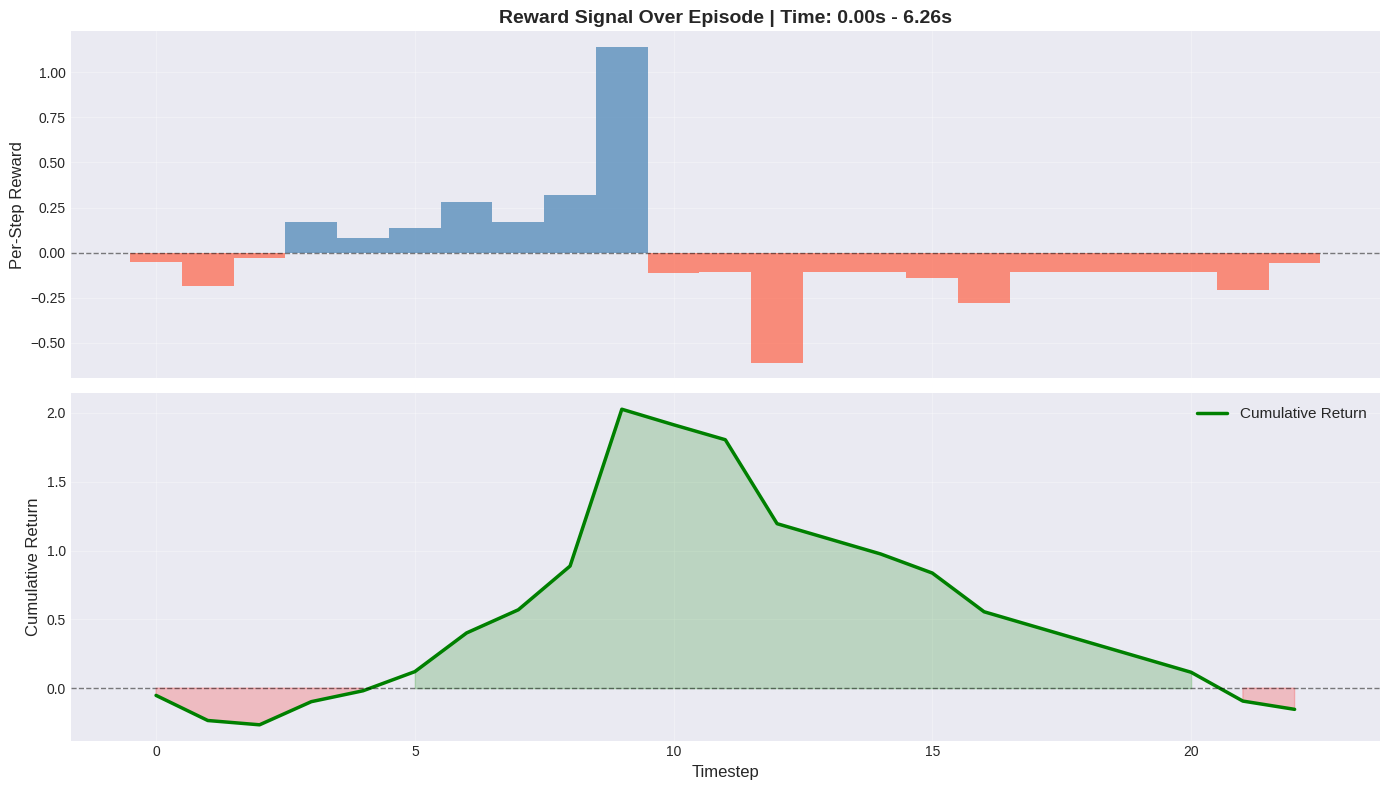

Reward visualization saved! Total return: -0.1539


In [101]:
# Section 4: Reward Over Time Visualization
if episode_data and rewards is not None:
    timesteps = np.arange(n_steps)
    cumulative_reward = np.cumsum(rewards)
    time_range = f"Time: {timestamps[0]:.2f}s - {timestamps[-1]:.2f}s"

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Top: per-step reward
    ax = axes[0]
    ax.bar(timesteps, rewards, color=np.where(rewards >= 0, 'steelblue', 'tomato'), alpha=0.7, width=1.0)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_ylabel('Per-Step Reward', fontsize=12)
    ax.set_title(f'Reward Signal Over Episode | {time_range}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)

    # Bottom: cumulative reward
    ax2 = axes[1]
    ax2.plot(timesteps, cumulative_reward, 'g-', linewidth=2.5, label='Cumulative Return')
    ax2.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax2.fill_between(timesteps, 0, cumulative_reward,
                     where=cumulative_reward >= 0, alpha=0.2, color='green')
    ax2.fill_between(timesteps, 0, cumulative_reward,
                     where=cumulative_reward < 0, alpha=0.2, color='red')
    ax2.set_xlabel('Timestep', fontsize=12)
    ax2.set_ylabel('Cumulative Return', fontsize=12)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/reward_over_time.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Reward visualization saved! Total return: {cumulative_reward[-1]:.4f}")
else:
    print("No rewards available - run cell 7 and 14 first")

## Section 5: Trajectory Visualization with Reward Overlay

Visualize the robot's exploration path in 2D/3D with reward heatmaps and sensor observations.

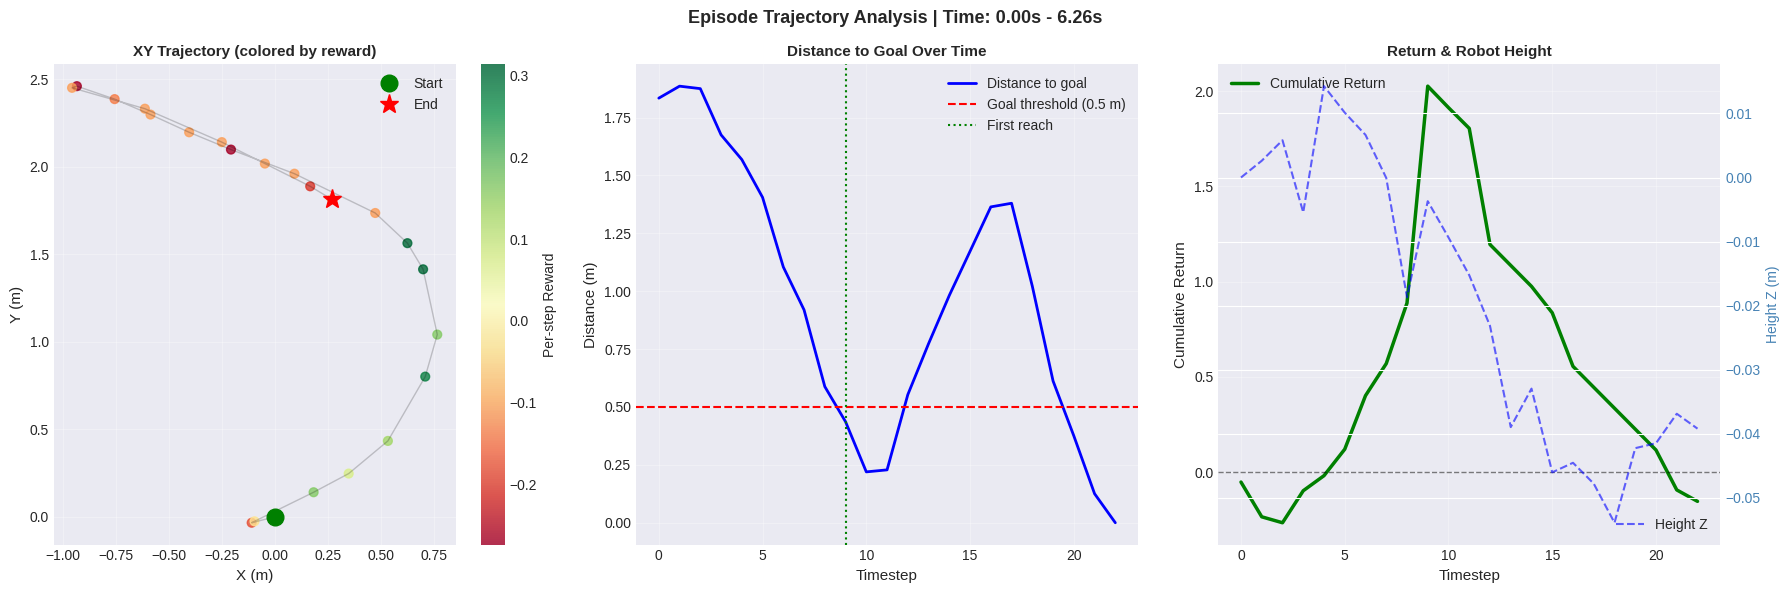

Trajectory visualization saved! Final return: -0.1539


In [102]:
# Section 5: Trajectory Visualization with Reward Overlay
if episode_data and rewards is not None and states is not None:
    positions = states[:n_steps, :2]       # (T, 2) XY positions
    heights   = states[:n_steps, 2]        # (T,) Z positions
    timesteps = np.arange(n_steps)
    cumulative_reward = np.cumsum(rewards)
    time_range = f"Time: {timestamps[0]:.2f}s - {timestamps[-1]:.2f}s"

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. XY trajectory coloured by per-step reward
    ax = axes[0]
    sc = ax.scatter(positions[:, 0], positions[:, 1],
                    c=rewards, cmap='RdYlGn', s=40, alpha=0.8,
                    vmin=np.percentile(rewards, 5), vmax=np.percentile(rewards, 95))
    ax.plot(positions[:, 0], positions[:, 1], 'k-', alpha=0.2, linewidth=1)
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=12, label='Start', zorder=5)
    ax.plot(positions[-1, 0], positions[-1, 1], 'r*', markersize=14, label='End', zorder=5)
    plt.colorbar(sc, ax=ax, label='Per-step Reward')
    ax.set_xlabel('X (m)', fontsize=11); ax.set_ylabel('Y (m)', fontsize=11)
    ax.set_title('XY Trajectory (colored by reward)', fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

    # 2. Distance-to-goal over time
    goal_pos = states[-1, :2]   # use final position as proxy for goal
    dist_to_goal = np.linalg.norm(positions - goal_pos, axis=1)
    ax2 = axes[1]
    ax2.plot(timesteps, dist_to_goal, 'b-', linewidth=2, label='Distance to goal')
    thresh = NOOBS_PARAMS.get('goal_reach_threshold', 0.5)
    ax2.axhline(thresh, color='red', linestyle='--', linewidth=1.5,
                label=f'Goal threshold ({thresh} m)')
    reach_steps = timesteps[dist_to_goal <= thresh]
    if len(reach_steps) > 0:
        ax2.axvline(reach_steps[0], color='green', linestyle=':', linewidth=1.5, label='First reach')
    ax2.set_xlabel('Timestep', fontsize=11); ax2.set_ylabel('Distance (m)', fontsize=11)
    ax2.set_title('Distance to Goal Over Time', fontsize=11, fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # 3. Cumulative return + robot height
    ax3 = axes[2]
    ax3.plot(timesteps, cumulative_reward, 'g-', linewidth=2.5, label='Cumulative Return')
    ax3.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax3b = ax3.twinx()
    ax3b.plot(timesteps, heights, 'b--', linewidth=1.5, alpha=0.6, label='Height Z')
    ax3b.set_ylabel('Height Z (m)', fontsize=10, color='steelblue')
    ax3b.tick_params(axis='y', labelcolor='steelblue')
    ax3.set_xlabel('Timestep', fontsize=11); ax3.set_ylabel('Cumulative Return', fontsize=11)
    ax3.set_title('Return & Robot Height', fontsize=11, fontweight='bold')
    ax3.legend(loc='upper left'); ax3b.legend(loc='lower right')
    ax3.grid(True, alpha=0.3)

    plt.suptitle(f'Episode Trajectory Analysis | {time_range}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/home/maurits-heemskerk/Documents/Uni/Master_Thesis/dreamer_SPOT_implementation/notebooks/trajectory_rewards.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Trajectory visualization saved! Final return: {cumulative_reward[-1]:.4f}")
else:
    print("Cannot visualize trajectory: missing states or rewards - run cells 5, 7, 14 first")

## Section 6: Noobs Reward Design (v2 — Distance-Decrease)

Current reward function (`compute_rewards_for_episode`, defined in cell 7):

| Component | Formula | Scale |
|-----------|---------|-------|
| **Distance-decrease** (primary) | `r(t) = dist(t-1) − dist(t)` · scale | 1.0 |
| **Goal-reach bonus** | `+0.5` one-time when `dist < 0.5 m` | — |
| **Out-of-radius penalty** | `−0.1/step` when leaving 1.0 m goal bubble | — |
| **Action smoothness** | `−scale · ‖Δa_continuous‖` (vx, vy, vyaw only) | 0.1 |
| **Orientation-to-goal** | `−scale · (1 − cos θ) / 2` | 0.2 |
| **Time penalty** | `−0.01` per step | — |

All parameters are in `NOOBS_PARAMS` (cell 6). Results are visualised in Sections 4 and 5.